# ILUSTR 4 — Normy wektorów, macierzy i funkcji: jedna liczba za „wielkość" obiektu

Pokrywa: slajdy 68–80 i 118–120 prezentacji ZW_1 oraz sekcje „normy wektorów",
„normy macierzy", „normy funkcji" konspektu ZW_1.

Problem: skalary porównujemy prosto (2 > 1), ale jak porównać **wektory błędu**, **macierze
przekształceń** albo **funkcje błędu**? Potrzebujemy reguły, która dowolnemu obiektowi
przypisze jedną liczbę nieujemną — jego „wielkość". To norma. W metodach numerycznych normy
są wszędzie: błąd rozwiązania wektorowego to norma wektora różnicy, uwarunkowanie to norma
macierzy, jakość aproksymacji funkcji to norma funkcji residuum.

Rozważymy normy Höldera $\|\mathbf{x}\|_p$ dla $p = 1, 2, \infty$ — dla wektorów, potem
macierzy, a na końcu funkcji (granica norm wektorów próbek).

Wektor błędu e = (7-3, 8-2) = (4, 6)
norma 1 : |4|+|6|              = 10
norma 2 : sqrt(4^2+6^2)        = 7.211103   (= 2*sqrt(13)
norma inf: max(|4|,|6|)        = 6


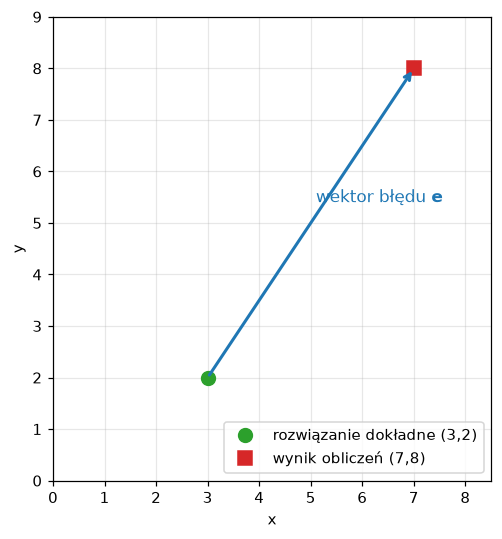

In [2]:
# Demo 1: wektor błędu z konspektu — trzy normy jednej wielkości.
# Rozwiązanie dokładne (3,2), przybliżone (7,8) — juz z konspektu/konspektu ZW_1.
import numpy as np
import matplotlib.pyplot as plt

x_dokl = np.array([3., 2.])
x_przy = np.array([7., 8.])
e = x_przy - x_dokl        # wektor błędu (4, 6)

print("Wektor błędu e = (7-3, 8-2) = (%g, %g)" % tuple(e))
print(f"norma 1 : |4|+|6|              = {np.abs(e).sum():.0f}")
print(f"norma 2 : sqrt(4^2+6^2)        = {np.linalg.norm(e):.6f}   (= 2*sqrt(13)")
print(f"norma inf: max(|4|,|6|)        = {np.abs(e).max():.0f}")

# Rysunek 3.34 z konspektu: punkt dokładny, przybliżony i wektor błędu.
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(*x_dokl, 'o', color='tab:green', ms=9, label='rozwiązanie dokładne (3,2)')
ax.plot(*x_przy, 's', color='tab:red', ms=9, label='wynik obliczeń (7,8)')
ax.annotate('', xy=x_przy, xytext=x_dokl, arrowprops=dict(arrowstyle='->', lw=2, color='tab:blue'))
ax.text(5.1, 5.4, 'wektor błędu $\\mathbf{e}$', color='tab:blue', fontsize=11)
ax.set_xlim(0, 8.5); ax.set_ylim(0, 9)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=.3); ax.set_aspect('equal')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

# WAZNE: norma 2 to "dlugosc strzalki" (odleglosc euklidesowa miedzy punktami),
# norma 1 to "droga przez rogi" (jak po manhattanu), norma inf to najwieksza pojedyncza
# wspolrzedna. Kazda mierzy cos innego, ale wszystkie zeruja sie <=> wektor zerowy.

## Kule jednostkowe: geometria zależna od normy

Konspekt pokazuje rysunki obszarów $\|\mathbf{x}\|_p \leq \delta$. Wygląd tych „kul"
(zbiorów punktów o normie nie większej niż $\delta$) zdradza, co dana norma uważa za
„wielkość" — i dlaczego wybór normy zmienia sens zdania „błąd jest mały".

Punkt (0.6, 0.8): ||p||_1 = 1.4, ||p||_2 = 1.000, ||p||_inf = 0.8
Wszystkie trzy normy mówią co innego o 'wielkości' tego samego wektora.


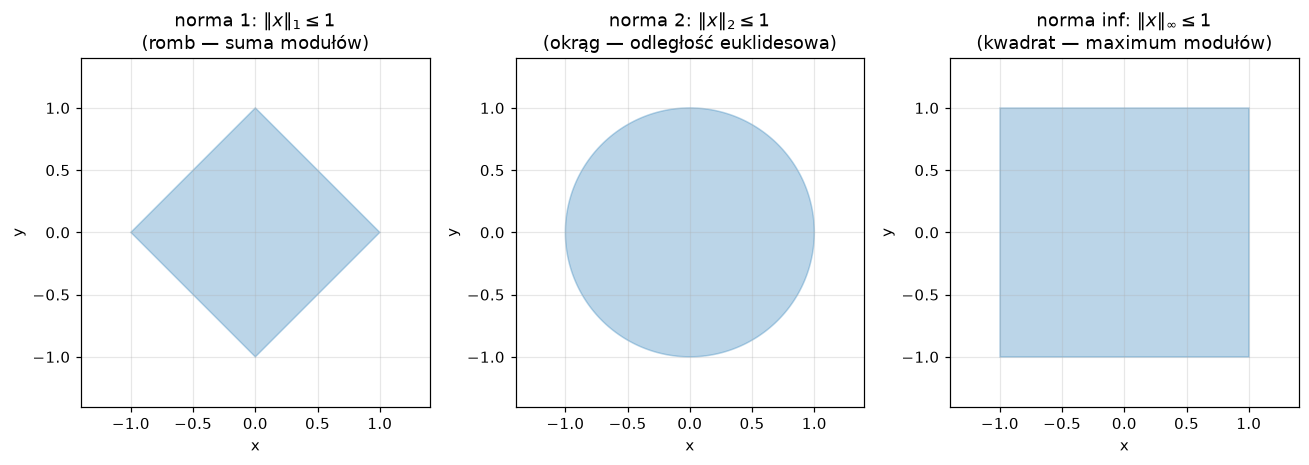

In [4]:
# Demo 2: kule jednostkowe trzech norm (regeneracja rysunku konspektu).
# Obszar ||x||_p <= 1: romb (p=1), kolo (p=2), kwadrat (p=inf).
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 400)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# p=1: |x|+|y| <= 1  -> romb
axes[0].fill([1, 0, -1, 0], [0, 1, 0, -1], alpha=.3, color='tab:blue')
axes[0].set_title('norma 1: $\\|x\\|_1 \\leq 1$\n(romb — suma modułów)')

# p=2: x^2+y^2 <= 1 -> okrag
axes[1].fill(np.cos(t), np.sin(t), alpha=.3, color='tab:blue')
axes[1].set_title('norma 2: $\\|x\\|_2 \\leq 1$\n(okrąg — odległość euklidesowa)')

# p=inf: max(|x|,|y|) <= 1 -> kwadrat
axes[2].fill([-1, 1, 1, -1], [-1, -1, 1, 1], alpha=.3, color='tab:blue')
axes[2].set_title('norma inf: $\\|x\\|_\\infty \\leq 1$\n(kwadrat — maximum modułów)')

for ax in axes:
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal'); ax.grid(alpha=.3); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

# Te same trzy normy punktu (0.6, 0.8):
p = np.array([0.6, 0.8])
print(f"Punkt (0.6, 0.8): ||p||_1 = {np.abs(p).sum():.1f}, ||p||_2 = {np.linalg.norm(p):.3f}, ||p||_inf = {np.abs(p).max():.1f}")
print("Wszystkie trzy normy mówią co innego o 'wielkości' tego samego wektora.")

## Norma macierzy: maksymalne rozciągnięcie przestrzeni

Macierz to przekształcenie. **Norma $p$ macierzy** to największe, o ile może rozciągnąć
dowolny wektor (w sensie normy $p$):

$$\|\mathbf{A}\|_p = \sup_{\mathbf{x} \neq 0} \frac{\|\mathbf{A}\mathbf{x}\|_p}{\|\mathbf.x\|_p}$$

Slajdy 77–79 pokazują to „od strony obrazka": bierzemy okrąg jednostkowy (zbior wektorów
o normie 2 równej 1) i patzymy, w co go macierz przekształci. Kształt wynikowy mówi,
jak silnie i w jakich kierunkach przekształcenie rozciąga przestrzeń — a jego najbardziej
wystający punkt to właśnie norma macierzy.

||diag(2,0.5)||_2  = 2.000
||odbicie||_2       = 1.000
||shear||_2         = 1.618  = (1+sqrt5)/2 = 1.618


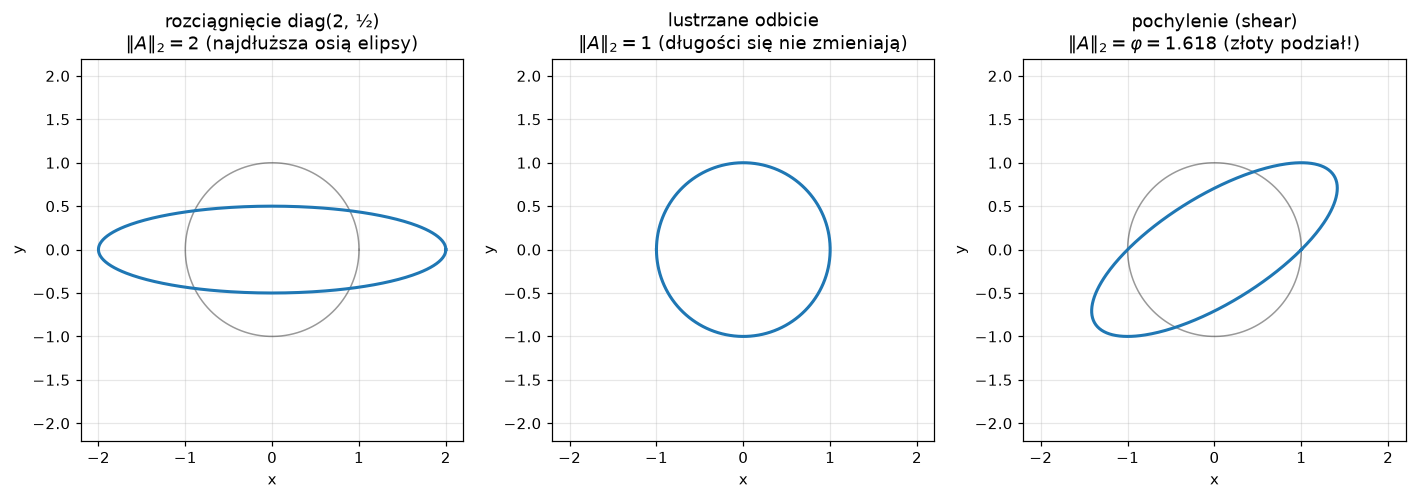

In [6]:
# Demo 3: okrąg jednostkowy przepuszczony przez różne macierze — norma jako "siega" przekształcenia.
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 400)
V = np.vstack([np.cos(t), np.sin(t)])     # okrag jednostkowy (2 x 400)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))

# (a) rozciagniecie: diag(2, 0.5)
A1 = np.diag([2., 0.5])
W1 = A1 @ V
axes[0].plot(*V, 'k', lw=1, alpha=.4); axes[0].plot(*W1, 'tab:blue', lw=2)
axes[0].set_title('rozciągnięcie diag(2, ½)\n$\\|A\\|_2 = 2$ (najdłuższa osią elipsy)')

# (b) lustrzane odbicie: [[-1,0],[0,1]]
A2 = np.array([[-1., 0.], [0., 1.]])
W2 = A2 @ V
axes[1].plot(*V, 'k', lw=1, alpha=.4); axes[1].plot(*W2, 'tab:blue', lw=2)
axes[1].set_title('lustrzane odbicie\n$\\|A\\|_2 = 1$ (długości się nie zmieniają)')

# (c) pochylenie (shear): [[1,1],[0,1]]
A3 = np.array([[1., 1.], [0., 1.]])
W3 = A3 @ V
axes[2].plot(*V, 'k', lw=1, alpha=.4); axes[2].plot(*W3, 'tab:blue', lw=2)
axes[2].set_title('pochylenie (shear)\n$\\|A\\|_2 = φ = 1.618$ (złoty podział!)')

for ax in axes:
    ax.set_aspect('equal'); ax.grid(alpha=.3); ax.set_xlabel('x'); ax.set_ylabel('y')
    lim = 2.2; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
plt.tight_layout(); plt.show()

# sprawdzenie numeryczne norm z obrazka:
print(f"||diag(2,0.5)||_2  = {np.linalg.norm(A1,2):.3f}")
print(f"||odbicie||_2       = {np.linalg.norm(A2,2):.3f}")
print(f"||shear||_2         = {np.linalg.norm(A3,2):.3f}  = (1+sqrt5)/2 = {(1+np.sqrt(5))/2:.3f}")

# Wnioski:
#  - rozciagniecie: norma to najwieksza polos elipsy (2) — najczulszy kierunek
#  - odbicie: norma 1 — zaden wektor nie rosnie, przekształcenie "nic nie wzmacnia"
#  - shear: elipsa pochyloNA, norma φ — kierunek maksymalnego rozciagniecia to NE (1,0)!
# W metodach numerycznych ||A|| wraca jako "mnożnik" w oszacowaniach błędu (rozd. o układy równań).

## Norma funkcji: granica normy wektora próbek

Funkcję na przedziale $[a,b]$ można potraktować jako wektor jej wartości w bardzo
gestej siatce punktów. Norma takiego wektora, w granicy $h \to 0$, to norma funkcji:

$$\|f\|_1 = \int_a^b |f|\,dx \quad \text{(pole pod |f|)}, \qquad
\|f\|_2 = \sqrt{\int_a^b f^2\,dx} \quad \text{(rms)}, \qquad
\|f\|_\infty = \sup |f| \quad \text{(maximum)}$$

To nie przypadek: norma 1 to **pole**, norma 2 to wartość skuteczna (rms — średnia
kwadratowa na jednostkę czasu), a norma nieskończoność to po prostu największe odchylenie.
Sprawdzimy zbieżność na żywo: tę samą funkcję próbkujemy coraz gęściej i patrzymy,
jak norma wektora dąży do normy funkcji.

In [8]:
# Demo 4: norma funkcji jako granica norm wektorow probek (zbieznosc na zywo).
import numpy as np
import matplotlib.pyplot as plt

# funkcja: f(t) = 1 + sin(t) na [0, 2pi]  (przesunięty sinus — nic nie ujemne)
Ns = [11, 51, 501, 5001, 50001]
norm1, norm2 = [], []
for N in Ns:
    t = np.linspace(0, 2*np.pi, N)
    h = t[1] - t[0]
    y = 1 + np.sin(t)
    norm1.append(np.abs(y).sum() * h)              # suma * krok -> pole
    norm2.append(np.sqrt((y**2).sum() * h))        # sqrt(suma kwadratow * krok) -> rms
    # norma inf bez zmian: max|f| = 2

print(f"{'N':>7} {'||f||_1 (wektor)':>18} {'||f||_2 (wektor)':>18}   normy graniczne:")
print(f"{'':>7} {'':>18} {'':>18}   ||f||_1 = 2pi = {2*np.pi:.4f}")
print(f"{'':>7} {'':>18} {'':>18}   ||f||_2 = sqrt(3*pi) = {np.sqrt(3*np.pi):.4f}")
for N, n1, n2 in zip(Ns, norm1, norm2):
    print(f"{N:7d} {n1:18.5f} {n2:18.5f}")

print()
print("Norma wektora próbki dąży do normy funkcji w miarę zagęszczania siatki.")
print("Norma 1 = pole pod |f|, norma 2 = rms * sqrt(b-a), norma inf = max |f| = 2.")

# Interpretacja "ile jest funkcji w przedziale" (konspekt): ||f||_1 to pole pod wykresem,
# ||f||_2 to skuteczna (rms) wielkość, ||f||_inf to najwieksze chwilowe odchylenie.

      N   ||f||_1 (wektor)   ||f||_2 (wektor)   normy graniczne:
                                                ||f||_1 = 2pi = 6.2832
                                                ||f||_2 = sqrt(3*pi) = 3.0700
     11            6.91150            3.17066
     51            6.40885            3.09038
    501            6.29575            3.07203
   5001            6.28444            3.07018
  50001            6.28331            3.07000

Norma wektora próbki dąży do normy funkcji w miarę zagęszczania siatki.
Norma 1 = pole pod |f|, norma 2 = rms * sqrt(b-a), norma inf = max |f| = 2.


## Najważniejsze wnioski

- Norma to jedna liczba opisująca „wielkość" obiektu — porównywać wektory/macierze/funkcje
  można dopiero po ustaleniu normy.
- Wektor błędu: $\|e\|_1$ = suma modułów, $\|e\|_2$ = odległość euklidesowa,
  $\|e\|_\infty$ = największa współrzędna — każda z nich jest poprawną miarą błędu
  rozwiązania, wybór zależy od tego, co boli (suma? odległość? najgorszy punkt?).
- Kule jednostkowe: romb / okrąg / kwadrat — wybór normy zmienia sens „małego błędu".
- Norma macierzy = maksymalne rozciągnięcie (najdłuższa półoś elipsy z okręgu jednostkowego);
  dla odbicia = 1, dla rozciągnięcia = największy współczynnik, dla shear = φ.
- Norma funkcji = granica normy wektora próbek: pole / rms / maximum. W aproksymacji
  norma funkcji residuum to właśnie „ile błędu jest w przybliżeniu na przedziale".

In [10]:
# ĆWICZENIE (szkielet — uzupełnij miejsca oznaczone TODO):
#
# 1) Policz wszystkie trzy normy wektora błędu e = (0.3, -0.4) i porównaj z (4,6).
#    Która norma zmienia się najbardziej po przeskalowaniu błędu 10x?
e = np.array([0.3, -0.4])
# TODO: print(np.abs(e).sum(), np.linalg.norm(e), np.abs(e).max())
# i dla 10*e: jak skaluja sie normy? (1: x10, 2: x10, inf: x10 — wszystkie normy sa jednorodne)

# 2) Narysuj okrag jednostkowy przepuszczony przez macierz [[1,2],[0,1]] (mocniejszy shear).
#    Oszacuj ||A||_2 z wykresu (najdalszy punkt elipsy) i zweryfikuj np.linalg.norm(A, 2).

# 3) Dla f(t) = sin(t) na [0, 4pi] policz numerycznie ||f||_1, ||f||_2, ||f||_inf
#    i porównaj z wartościami analitycznymi: 8, sqrt(2*pi), 1.
t = np.linspace(0, 4*np.pi, 100001)
# TODO: policz h, ||1||, ||2||, ||inf|| dla sin


## Wykorzystywane funkcje

- `np.linalg.norm(x, p)` — norma $p$ wektora lub macierzy (dla macierzy liczona przez SVD),
- `np.diag`, `A @ V` — budowanie macierzy przekształceń i mnożenie wszystkich punktów naraz,
- `np.linspace`, `plt.fill` — rysowanie kul jednostkowych i elips obrazów okręgu.

## Ćwiczenie — wskazówki

1) jedna linijka na normę; skalowanie przez $c$ mnoży normę przez $|c|$ (jednorodność) —
   to jedna z aksjomatów normy, które widać natychmiast numerycznie.
2) elipsa z shear [[1,2],[0,1]]: jej najdłuższa półoś to $1+\sqrt{2}+\ldots$ policz
   numerycznie i porównaj z wartością własną — dla macierzy symetrycznej
   $\|A\|_2 = \max|\lambda|$.
3) $\int_0^{4\pi}|\sin| = 8$ (dwa pełne okresy po 4), $\int \sin^2 = \pi$ na każdym okresie —
   policz przez sumę $\cdot h$.